<a href="https://colab.research.google.com/github/ojassahu29/6DOF-Robotics-Full-Fledged-Project/blob/main/Assignment2_2023A3PS0861G.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Assignment 2

####Ojas Sahu
####2023A3PS0861G


###Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

###Question 1:  Implementation of Linear Kalman Filter

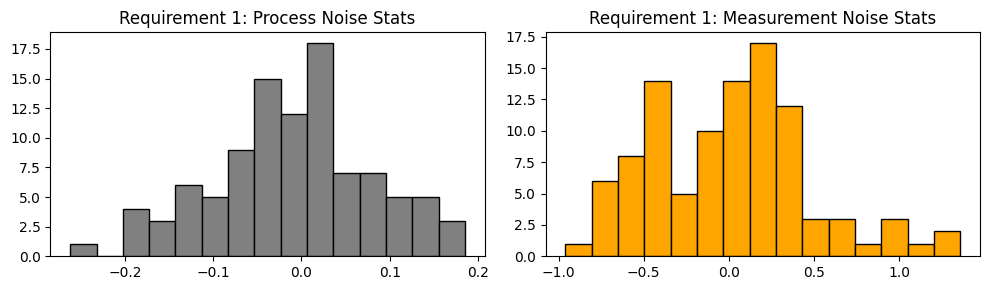

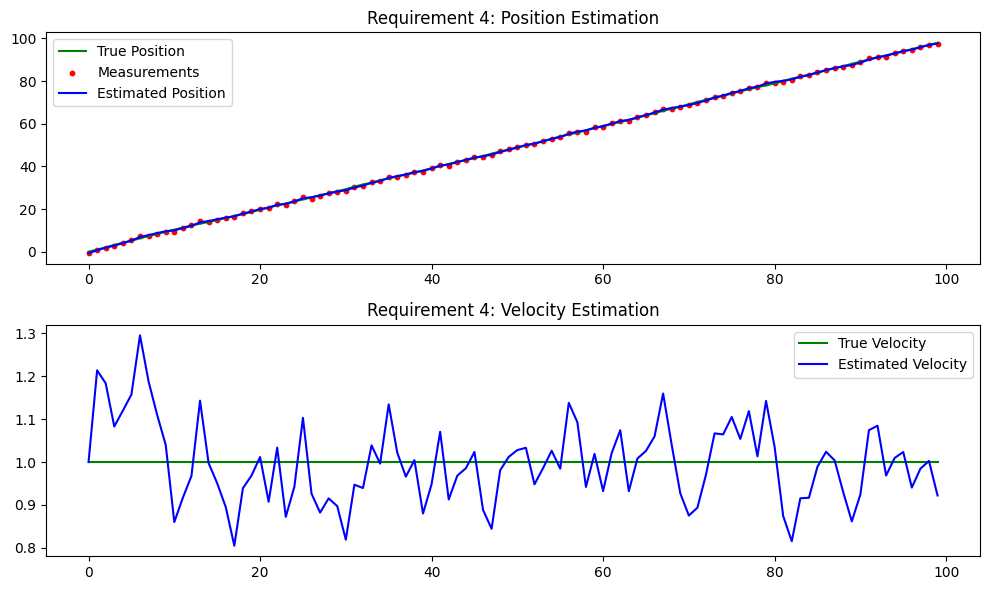

Position RMSE: 0.2933659562065716
Velocity RMSE: 0.0930859959059235


In [ ]:
np.random.seed(42)
dt = 1.0
N = 100
true_velocity = 1.0
process_std = 0.1
measurement_std = 0.5
w_samples = np.random.normal(0, process_std, N)
v_samples = np.random.normal(0, measurement_std, N)
x_true = np.zeros(N)
v_true = np.ones(N) * true_velocity
for k in range(1, N):
    x_true[k] = x_true[k-1] + v_true[k-1]*dt + w_samples[k]
z = x_true + v_samples

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.hist(w_samples, bins=15, color='gray', edgecolor='black')
plt.title("Requirement 1: Process Noise Stats")
plt.subplot(1, 2, 2)
plt.hist(v_samples, bins=15, color='orange', edgecolor='black')
plt.title("Requirement 1: Measurement Noise Stats")
plt.tight_layout()
plt.show()

A = np.array([[1, dt], [0, 1]])
H = np.array([[1, 0]])
Q = np.array([[process_std**2, 0], [0, process_std**2]])
R = np.array([[measurement_std**2]])
x_est = np.zeros((2, N))
P = np.eye(2)
x_est[:, 0] = [z[0], 1.0]

for k in range(1, N):
    x_pred = A @ x_est[:, k-1]
    P_pred = A @ P @ A.T + Q
    K = P_pred @ H.T @ np.linalg.inv(H @ P_pred @ H.T + R)
    y = z[k] - H @ x_pred
    x_est[:, k] = x_pred + (K @ y).flatten()
    P = (np.eye(2) - K @ H) @ P_pred

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(x_true, label="True Position", color='g')
plt.scatter(range(N), z, label="Measurements", color='r', s=10)
plt.plot(x_est[0, :], label="Estimated Position", color='b')
plt.title("Requirement 4: Position Estimation")
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(v_true, label="True Velocity", color='g')
plt.plot(x_est[1, :], label="Estimated Velocity", color='b')
plt.title("Requirement 4: Velocity Estimation")
plt.legend()
plt.tight_layout()
plt.show()

rmse_p = np.sqrt(np.mean((x_true - x_est[0,:])**2))
rmse_v = np.sqrt(np.mean((v_true - x_est[1,:])**2))
print(f"Position RMSE: {rmse_p}")
print(f"Velocity RMSE: {rmse_v}")

### Question 2: Extended Kalman Filter (EKF) for Nonlinear System

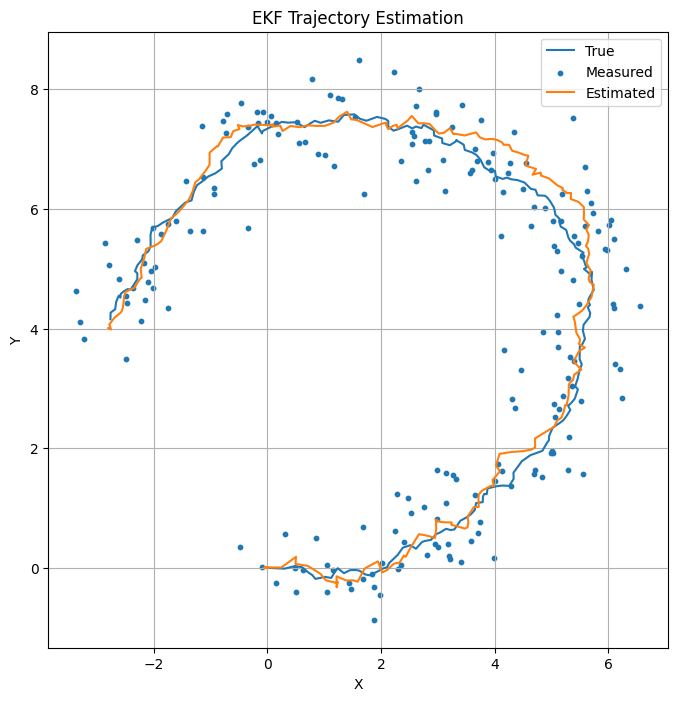

RMSE X: 0.13206549254062436
RMSE Y: 0.2524537467540075


In [ ]:
np.random.seed(42)

dt = 0.1
N = 200

v = 1.0
omega = 0.2

process_std = np.array([0.05, 0.05, 0.02])
measurement_std = 0.5

x_true = np.zeros((3, N))
z = np.zeros((2, N))

for k in range(1, N):
    w = np.random.normal(0, process_std)
    x_true[0,k] = x_true[0,k-1] + v*np.cos(x_true[2,k-1])*dt + w[0]
    x_true[1,k] = x_true[1,k-1] + v*np.sin(x_true[2,k-1])*dt + w[1]
    x_true[2,k] = x_true[2,k-1] + omega*dt + w[2]

z[0,:] = x_true[0,:] + np.random.normal(0, measurement_std, N)
z[1,:] = x_true[1,:] + np.random.normal(0, measurement_std, N)

x_est = np.zeros((3, N))
P = np.eye(3)

Q = np.diag(process_std**2)
R = np.eye(2) * measurement_std**2

H = np.array([[1,0,0],
              [0,1,0]])

for k in range(1, N):

    theta = x_est[2,k-1]

    x_pred = np.zeros(3)
    x_pred[0] = x_est[0,k-1] + v*np.cos(theta)*dt
    x_pred[1] = x_est[1,k-1] + v*np.sin(theta)*dt
    x_pred[2] = x_est[2,k-1] + omega*dt

    F = np.array([
        [1, 0, -v*np.sin(theta)*dt],
        [0, 1,  v*np.cos(theta)*dt],
        [0, 0, 1]
    ])

    P_pred = F @ P @ F.T + Q

    K = P_pred @ H.T @ np.linalg.inv(H @ P_pred @ H.T + R)

    y = z[:,k] - H @ x_pred

    x_est[:,k] = x_pred + K @ y
    P = (np.eye(3) - K @ H) @ P_pred

plt.figure(figsize=(8,8))
plt.plot(x_true[0,:], x_true[1,:])
plt.scatter(z[0,:], z[1,:], s=10)
plt.plot(x_est[0,:], x_est[1,:])
plt.legend(["True", "Measured", "Estimated"])
plt.xlabel("X")
plt.ylabel("Y")
plt.title("EKF Trajectory Estimation")
plt.grid()
plt.show()

rmse_x = np.sqrt(np.mean((x_true[0,:] - x_est[0,:])**2))
rmse_y = np.sqrt(np.mean((x_true[1,:] - x_est[1,:])**2))

print("RMSE X:", rmse_x)
print("RMSE Y:", rmse_y)

### Question 3: Kalman Filter Tuning and Convergence Analysis (used Question 1)

Low Q, High R (Trust Model) | Total RMSE: 0.2659 | Steady RMSE: 0.2324
Balanced (True Noise Match) | Total RMSE: 0.2966 | Steady RMSE: 0.3123
High Q, Low R (Trust Sensor) | Total RMSE: 0.4693 | Steady RMSE: 0.4302


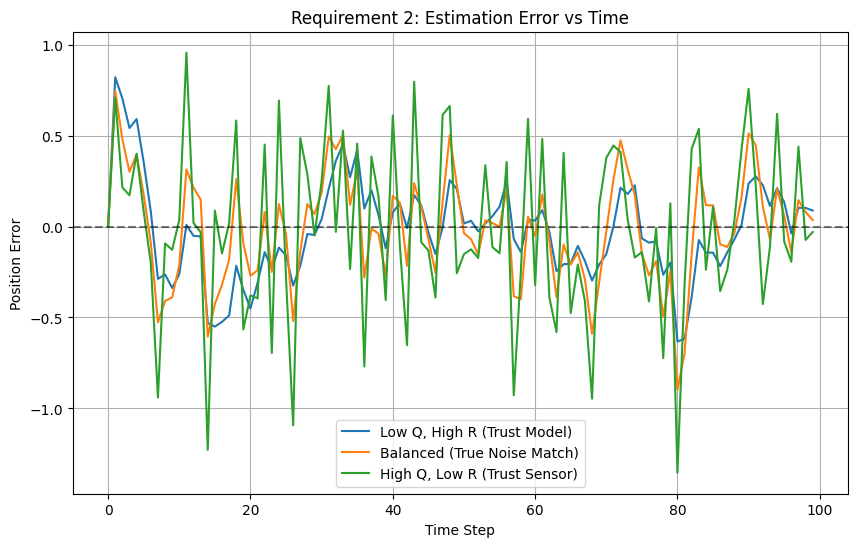

In [ ]:
np.random.seed(42)
dt = 1.0
N = 100
true_velocity = 1.0
process_std_true = 0.1
measurement_std_true = 0.5

x_true = np.zeros(N)
v_true = np.ones(N) * true_velocity
for k in range(1, N):
    w = np.random.normal(0, process_std_true)
    x_true[k] = x_true[k-1] + v_true[k-1]*dt + w
z = x_true + np.random.normal(0, measurement_std_true, N)

A = np.array([[1, dt], [0, 1]])
H = np.array([[1, 0]])

settings = [
    {"Q": 0.001, "R": 1.0,  "label": "Low Q, High R (Trust Model)"},
    {"Q": 0.01,  "R": 0.25, "label": "Balanced (True Noise Match)"},
    {"Q": 1.0,   "R": 0.01, "label": "High Q, Low R (Trust Sensor)"}
]

plt.figure(figsize=(10, 6))

for s in settings:
    Q = np.eye(2) * s["Q"]
    R = np.array([[s["R"]]])
    x_est = np.zeros((2, N))
    P = np.eye(2)
    error = np.zeros(N)

    for k in range(1, N):
        x_pred = A @ x_est[:, k-1]
        P_pred = A @ P @ A.T + Q
        K = P_pred @ H.T @ np.linalg.inv(H @ P_pred @ H.T + R)
        y = z[k] - H @ x_pred
        x_est[:, k] = x_pred + (K @ y).flatten()
        P = (np.eye(2) - K @ H) @ P_pred
        error[k] = x_true[k] - x_est[0, k]

    rmse = np.sqrt(np.mean(error**2))
    steady_rmse = np.sqrt(np.mean(error[int(N*0.7):]**2))

    print(f"{s['label']} | Total RMSE: {rmse:.4f} | Steady RMSE: {steady_rmse:.4f}")
    plt.plot(error, label=s["label"])

plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title("Requirement 2: Estimation Error vs Time")
plt.xlabel("Time Step")
plt.ylabel("Position Error")
plt.legend()
plt.grid(True)
plt.show()